# 🛡️ RakshaSutra — Dataset Generation & Exploratory Data Analysis
**Phase 2 | IIT Hackathon | Multilingual Fraud Detection**

This notebook covers:
1. Generating the multilingual fraud dataset (8 Indian languages)
2. Merging all data sources
3. EDA — class distribution, language breakdown, message length analysis
4. Dataset quality checks (deduplication, balance)


## 📦 Step 1 — Install & Import Dependencies

In [1]:
# Install required packages (run once)
# !pip install pandas matplotlib seaborn scikit-learn xgboost sentence-transformers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import csv, random, os, warnings

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# Plot style
plt.rcParams.update({'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
                     'axes.edgecolor': '#444', 'text.color': 'white',
                     'axes.labelcolor': 'white', 'xtick.color': 'white',
                     'ytick.color': 'white', 'grid.color': '#333',
                     'font.family': 'monospace'})

print("✅ Libraries loaded successfully")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")


✅ Libraries loaded successfully
   Pandas  : 2.3.3
   NumPy   : 2.3.3


## 🌍 Step 2 — Multilingual Fraud Message Templates

In [2]:
# ── Fraud message templates per language ──────────────────────
templates = {
"English": {
  "spam": [
    "You have WON Rs {amt} lakh in our lucky draw! Click {url} to claim NOW",
    "URGENT: Your {bank} account is BLOCKED. Verify KYC at {url} within 24 hours",
    "FREE iPhone {model} for first 100 users! WhatsApp your address to {phone}",
    "Earn Rs {amt2} per month from home! No experience needed. Join now {url}",
    "Congratulations! You are selected for Rs {amt} lakh government scheme. Share OTP",
    "Your PAN card will be DEACTIVATED. Update immediately at {url}",
    "Investment offer: Double your money in {days} days. 100% guaranteed returns!",
    "ALERT: Your electricity will be cut TODAY. Pay Rs {amt2} now at {url}",
    "Get loan Rs {amt} lakh in 10 minutes. No documents required. Apply: {url}",
    "Amazon lucky draw winner! Rs {amt2} prize waiting. Share bank details now",
    "Suspicious login on your account! Verify OTP immediately or lose access",
    "Work from home job: Rs {amt2}/hour data entry. Register: {url}",
    "Your Aadhaar linked mobile will be blocked. Update KYC now: {url}",
    "Crypto investment: 300% profit guaranteed in {days} days. Limited slots!",
    "Send Rs 999 registration fee to claim your Rs {amt} lakh lottery prize",
    "Dear customer your SBI account shows unusual activity. Call {phone} now",
    "Police case registered against your Aadhaar. Call {phone} to resolve now",
  ],
  "ham": [
    "Can you pick me up from the station at 6?",
    "Happy birthday! Hope you have a great day",
    "The meeting has been rescheduled to Thursday at 3pm",
    "Did you watch the match last night? What a game!",
    "Please bring milk and bread on your way home",
    "Mom is coming to visit next weekend, please clean up",
    "I submitted the assignment. Can you review it when free?",
    "Let us meet for lunch tomorrow at the usual place",
    "Good morning! How are you feeling today?",
    "The project deadline has been extended by two days",
    "Can you share the notes from today's lecture?",
    "Dinner is ready, come home soon",
    "My train is delayed by 30 minutes, wait for me",
    "Happy anniversary to you both!",
    "The wifi is not working, can you check the router?",
  ]
},
"Hindi": {
  "spam": [
    "{amt} lakh rupaye jeetne ka mauka! Abhi UPI se paisa bhejo: {phone}",
    "TATKAL: Aapka {bank} account band hone wala hai. OTP share karein abhi",
    "Muft iPhone {model} milega pehle 50 logon ko. Abhi WhatsApp karein: {phone}",
    "Ghar baithe Rs {amt2} kamao. Koi anubhav zaroori nahi. Register: {url}",
    "Badhai ho! Aapko {amt} lakh ki PM yojana mein chunaa gaya hai. OTP dijiye",
    "Bijli aaj katne waali hai. Abhi Rs {amt2} bharein: {url} warna connection katega",
    "Loan Rs {amt} lakh sirf 10 minute mein. Koi document nahi. Click: {url}",
    "Police ne tera Aadhaar flag kiya hai. {phone} par call kar turant",
  ],
  "ham": [
    "Kal subah 8 baje milte hain station par",
    "Maa ka phone aaya tha, callback karna",
    "Khana ready hai, aa jao ghar",
    "Aaj bahut thaka hua feel ho raha hai yaar",
    "Meeting 3 baje hai, mat bhoolna",
    "Aaj barish ho rahi hai, chata le lena",
    "Raat ko kya khaoge, bata do main bana deti hun",
  ]
},
"Marathi": {
  "spam": [
    "Tumchya naavavar {amt} lakh chi lottery! Aadhaar ani OTP pathva: {phone}",
    "Tatkal: Aapale {bank} khate band hoil. KYC update kara: {url}",
    "TATKAL: Tumchi vij jodhani aaj tutil. Rs {amt2} bhara: {url}",
    "Sarkar yojaneysaathi {amt} lakh milel. OTP share kara aata",
    "Police complaint file zali aahe tumchya varun. {phone} la call kara",
  ],
  "ham": [
    "Kal savali yetoy aajoba, tayar raha",
    "Jevanayla ya sange, ready aahe",
    "Paaus padto aahe, chhatri gheun ye",
    "Bhai chi gaadi khali aahe ka aaj",
  ]
},
"Telugu": {
  "spam": [
    "Meeru {amt} lakhalu lottery gelichaaru! OTP cheppandi: {phone}",
    "TATKAL: Mee {bank} account band avutundi. KYC verify cheyyandi: {url}",
    "TATKAL: Mee electricity cut avutundi. Rs {amt2} pay cheyyandi: {url}",
    "Police complaint mee meeda. {phone} lo call cheyyandi tatkal",
  ],
  "ham": [
    "Naadu ela unnaru, cheppandi",
    "Repu kaluddaam, time cheppandi",
    "Intiki epudu vastunnaru, tindhi ready",
    "Exam ela jaindhi, result vacchindaa",
  ]
},
"Tamil": {
  "spam": [
    "Ungalukku {amt} lakh lottery당chendrukkireer! OTP sollunga: {phone}",
    "AVASARAM: Ungal {bank} account block aagidum. KYC verify pannunga: {url}",
    "AVASARAM: Ungal min connection indru tundikkappadum. Rs {amt2} pay pannunga: {url}",
    "Police complaint ungal peru. {phone} ku call pannunga tatkal",
  ],
  "ham": [
    "Naaley santhippoma, time sollunga",
    "Veetukku eppo varuveengal, saapidu ready",
    "Mazhai varuthu, kudai eduthukko",
    "Doctor appointment confirm aachaa",
  ]
},
"Bengali": {
  "spam": [
    "Apnar naame {amt} lakh taka lottery! Ekhoni OTP pathaan: {phone}",
    "TATKAL: Apnar {bank} account band hoye jabe. KYC update korun: {url}",
    "Police complaint apnar biruddhe. {phone} te call korun ekhoni",
  ],
  "ham": [
    "Kal subhey dekha hobe, thik ache",
    "Bari kakhon ashbe bolo, ranna ready",
    "Bristi hochhe, chhata niye jao",
  ]
},
"Gujarati": {
  "spam": [
    "Tamaara naam par {amt} lakh lottery! Hame OTP moklo: {phone}",
    "TATKAL: Tamaaro {bank} account band thase. KYC update karo: {url}",
    "Police farad tamara viruddh. {phone} par call karo taatkaL",
  ],
  "ham": [
    "Kal savare maLiye, samay jaNaavo",
    "Mazhai che, chhatri lejo",
    "Doctor no appointment confirm che ke",
  ]
},
"Hinglish": {
  "spam": [
    "Bhai {amt} lakh ka prize tere liye! Abhi claim kar: {url}",
    "Tera {bank} account suspend ho gaya! Turant OTP share kar {phone}",
    "Loan chahiye? {amt} lakh milenge 5 minute mein. Documents nahi chahiye: {url}",
  ],
  "ham": [
    "Yaar kal party hai tere ghar pe, kya plan hai",
    "Office se nikal gaya hun 30 minute mein aa jaunga",
    "Kal interview hai mera, dua karna",
  ]
},
}

substitutions = {
    "{amt}":   ["5","10","15","20","25","30","50"],
    "{amt2}":  ["800","1200","1500","2000","3500","5000","8000","10000","25000","40000"],
    "{days}":  ["7","10","15","30"],
    "{bank}":  ["SBI","HDFC","ICICI","Axis","PNB","Kotak"],
    "{model}": ["14","15","15 Pro","16"],
    "{phone}": ["9876543210","8765432109","7654321098","6543210987"],
    "{url}":   ["bit.ly/claim99","tinyurl.com/prize1","rb.gy/win25","cutt.ly/reward"],
}

def fill(template):
    for k, options in substitutions.items():
        if k in template:
            template = template.replace(k, random.choice(options), 1)
    return template

print("✅ Templates defined for 8 languages")
print(f"   Total spam templates  : {sum(len(v['spam']) for v in templates.values())}")
print(f"   Total ham templates   : {sum(len(v['ham']) for v in templates.values())}")


✅ Templates defined for 8 languages
   Total spam templates  : 47
   Total ham templates   : 43


## ⚙️ Step 3 — Generate Dataset with Augmentation

In [3]:
rows = []
for lang, groups in templates.items():
    for lbl, msgs in groups.items():
        count = random.randint(3, 5) if lbl == "spam" else 2
        for msg in msgs:
            for _ in range(count):
                rows.append({"label": lbl, "text": fill(msg), "language": lang})

random.shuffle(rows)
df_v2 = pd.DataFrame(rows)
df_v2.to_csv("multilingual_fraud_dataset_v2.csv", index=False)

print(f"✅ Generated {len(df_v2)} samples")
print(f"   SPAM : {(df_v2.label=='spam').sum()}")
print(f"   HAM  : {(df_v2.label=='ham').sum()}")


✅ Generated 290 samples
   SPAM : 204
   HAM  : 86


## 🔗 Step 4 — Merge All Data Sources

In [4]:
frames = []

# Original English SMS spam dataset (download from Kaggle)
try:
    d = pd.read_csv("spam.csv", encoding="latin-1")[["v1","v2"]]
    d.columns = ["label","text"]; d["language"] = "English"
    frames.append(d)
    print(f"spam.csv           : {len(d):>5} rows")
except FileNotFoundError:
    print("spam.csv           : [SKIP] Download from kaggle.com/datasets/uciml/sms-spam-collection-dataset")

# Phase 1 multilingual dataset
try:
    d = pd.read_csv("multilingual_fraud_dataset.csv")
    if "language" not in d.columns: d["language"] = "Mixed"
    frames.append(d)
    print(f"multilingual v1    : {len(d):>5} rows")
except FileNotFoundError:
    print("multilingual v1    : [SKIP]")

# Phase 2 dataset (just generated above)
frames.append(df_v2)
print(f"multilingual v2    : {len(df_v2):>5} rows")

# Hard edge case samples
try:
    d = pd.read_csv("hard_samples.csv")
    frames.append(d)
    print(f"hard_samples       : {len(d):>5} rows")
except FileNotFoundError:
    print("hard_samples       : [SKIP]")

df = pd.concat(frames, ignore_index=True).dropna(subset=["label","text"])
df["text"]  = df["text"].astype(str).str.strip()
df["label"] = df["label"].str.strip().str.lower()
df = df[df["label"].isin(["spam","ham"])]

before = len(df)
df = df.drop_duplicates(subset=["text"])
print(f"\nAfter dedup        : {len(df):>5} rows (removed {before - len(df)} duplicates)")
print(f"Final SPAM         : {(df.label=='spam').sum():>5}")
print(f"Final HAM          : {(df.label=='ham').sum():>5}")

df.to_csv("dataset.csv", index=False)
print("\n✅ dataset.csv saved")


spam.csv           :  5572 rows
multilingual v1    :   600 rows
multilingual v2    :   290 rows
hard_samples       :    47 rows

After dedup        :  5652 rows (removed 857 duplicates)
Final SPAM         :  1057
Final HAM          :  4595

✅ dataset.csv saved


## 📊 Step 5 — Exploratory Data Analysis

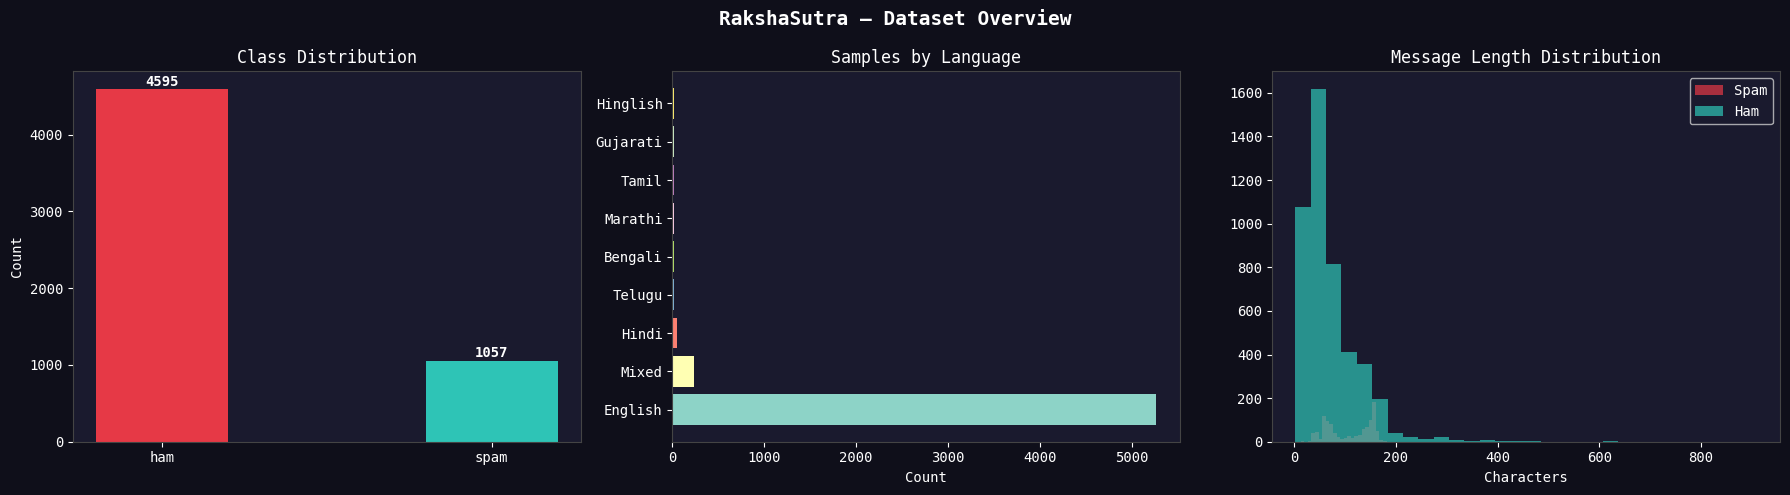

✅ EDA plot saved as eda_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RakshaSutra — Dataset Overview", fontsize=14, color='white', fontweight='bold')

# 1. Class distribution
ax = axes[0]
counts = df["label"].value_counts()
colors = ['#e63946', '#2ec4b6']
bars = ax.bar(counts.index, counts.values, color=colors, width=0.4, edgecolor='none')
ax.set_title("Class Distribution", color='white')
ax.set_ylabel("Count", color='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', color='white', fontweight='bold')

# 2. Language breakdown
ax = axes[1]
if "language" in df.columns:
    lang_counts = df["language"].value_counts()
    palette = plt.cm.Set3(np.linspace(0, 1, len(lang_counts)))
    ax.barh(lang_counts.index, lang_counts.values, color=palette, edgecolor='none')
    ax.set_title("Samples by Language", color='white')
    ax.set_xlabel("Count", color='white')

# 3. Message length distribution
ax = axes[2]
df["msg_len"] = df["text"].str.len()
spam_len = df[df.label=="spam"]["msg_len"]
ham_len  = df[df.label=="ham"]["msg_len"]
ax.hist(spam_len, bins=30, alpha=0.7, color='#e63946', label='Spam', edgecolor='none')
ax.hist(ham_len,  bins=30, alpha=0.7, color='#2ec4b6', label='Ham',  edgecolor='none')
ax.set_title("Message Length Distribution", color='white')
ax.set_xlabel("Characters", color='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print("✅ EDA plot saved as eda_overview.png")


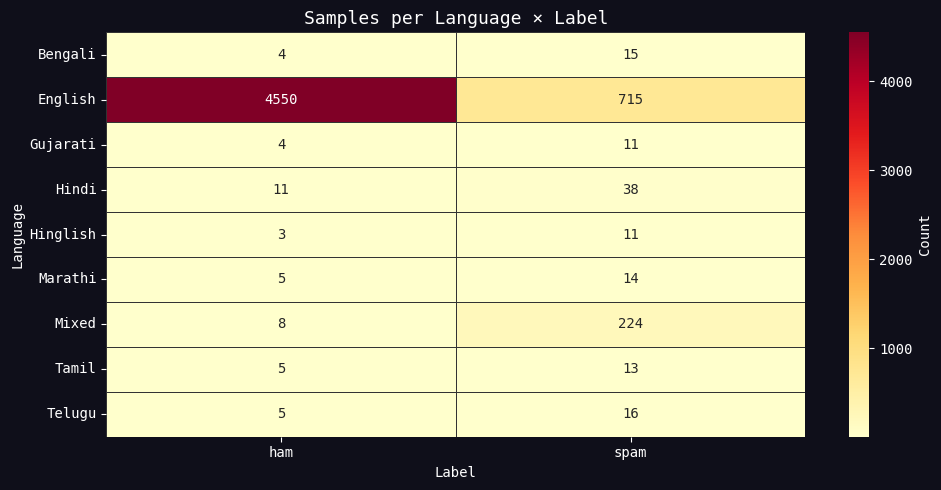

✅ Heatmap saved as eda_heatmap.png


In [6]:
# Language × Label heatmap
if "language" in df.columns:
    pivot = df.groupby(["language","label"]).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#0f0f1a')
    
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
                ax=ax, linewidths=0.5, linecolor='#333',
                cbar_kws={'label': 'Count'})
    ax.set_title("Samples per Language × Label", color='white', fontsize=13)
    ax.set_xlabel("Label", color='white')
    ax.set_ylabel("Language", color='white')
    ax.tick_params(colors='white')
    
    plt.tight_layout()
    plt.savefig("eda_heatmap.png", dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print("✅ Heatmap saved as eda_heatmap.png")


In [7]:
# Dataset summary statistics
print("="*50)
print("  DATASET QUALITY REPORT")
print("="*50)
print(f"  Total samples      : {len(df)}")
print(f"  Spam               : {(df.label=='spam').sum()} ({(df.label=='spam').mean()*100:.1f}%)")
print(f"  Ham                : {(df.label=='ham').sum()} ({(df.label=='ham').mean()*100:.1f}%)")
print(f"  Avg spam length    : {df[df.label=='spam']['msg_len'].mean():.0f} chars")
print(f"  Avg ham length     : {df[df.label=='ham']['msg_len'].mean():.0f} chars")
if "language" in df.columns:
    print(f"  Languages covered  : {df['language'].nunique()}")
print(f"  Duplicates removed : yes")
print("="*50)


  DATASET QUALITY REPORT
  Total samples      : 5652
  Spam               : 1057 (18.7%)
  Ham                : 4595 (81.3%)
  Avg spam length    : 109 chars
  Avg ham length     : 70 chars
  Languages covered  : 9
  Duplicates removed : yes
